# 🏡 California Housing Price Prediction using Linear Regression

## Project Overview

This notebook presents an end-to-end Machine Learning workflow for predicting house prices using the California Housing Dataset.

The project demonstrates every essential stage of a supervised regression pipeline, including data loading, exploration, preprocessing, feature scaling, model training, evaluation, and visualization.

The objective is not only to build an accurate predictive model, but also to understand the complete Machine Learning workflow used in real-world projects.

---

## Objectives

- Load and inspect a real-world dataset.
- Handle missing values.
- Prepare the data for Machine Learning.
- Split the dataset into training and testing sets.
- Normalize numerical features using StandardScaler.
- Train a Linear Regression model.
- Evaluate the model using multiple regression metrics.
- Visualize both the dataset and the model's predictions.

---

## Dataset

Dataset: California Housing Dataset

Target Variable: median_house_value

The dataset contains demographic, geographic, and housing-related information collected from districts in California.

---

## Technologies Used

- Python
- NumPy
- Pandas
- Matplotlib
- Scikit-learn

---

## Machine Learning Workflow

1. Import Libraries
2. Load the Dataset
3. Explore the Dataset
4. Handle Missing Values
5. Prepare Features and Target
6. Split the Dataset
7. Feature Scaling
8. Train the Linear Regression Model
9. Make Predictions
10. Evaluate the Model
11. Visualize the Results

---

Author: Hussein Walid




---

## 1. Import Required Libraries


In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)



## 2. Load Dataset

In [2]:
df = pd.read_csv("Data/California_Housing.csv")


## 3. Explore the Dataset

### 1. Display the First Five Rows

In [4]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


### 2. Dataset Information

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


### 3. Statistical Summary

In [6]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


## 4. Handle Missing Values
In this section:
- Missing numerical values are replaced by the column's mean
- Missing cateforial values are replaced by the column's Mode
- Rows with missing target value will be removed
  

In [7]:
 df = df.dropna(subset=["median_house_value"])
 for col_name in df.columns:
     if not df[col_name].isna().any():
         continue
     if pd.api.types.is_numeric_dtype(df[col_name]):
        mean = df[col_name].mean()
        df[col_name] = df[col_name].fillna(mean)
     else:
        mode = df[col_name].mode()
        df[col_name] = df[col_name].fillna(mode.iloc[0])

### Check Replacing NaNs Values  

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20640 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


## 5. Prepare Features and Target

Machine Learning models require the input features (X) and the target variable (y) to be separated before training.

In this step, the target column (median_house_value) is extracted as the prediction target, while the remaining numerical features are used as the model's input. Categorical features are excluded at this stage to ensure that the feature matrix contains only numerical values compatible with the Linear Regression algorithm.


In [9]:
    y = df["median_house_value"].to_numpy()
    df_features = df.drop("median_house_value",axis=1)
    columns_to_drop = [ ]
    for col_name in df_features.columns:
        if not pd.api.types.is_numeric_dtype(df_features[col_name]):
            columns_to_drop.append(col_name)
    df_features = df_features.drop(columns=columns_to_drop)
    X = df_features.to_numpy()

### Verify the Feature Matrix 
Before splitting the dataset , we inspect the feature matrix to ensure that all remaining features are numerical.

In [10]:
print("Feature Matrix Shape : ",X.shape)
print("The First 3 Rows in Feature Matrix :- ")
print(X[:3])

Feature Matrix Shape :  (20640, 8)
The First 3 Rows in Feature Matrix :- 
[[-122.23     37.88     41.      880.      129.      322.      126.
     8.3252]
 [-122.22     37.86     21.     7099.     1106.     2401.     1138.
     8.3014]
 [-122.24     37.85     52.     1467.      190.      496.      177.
     7.2574]]


## 6. Split the Dataset (Training/Testing) Sets
Where 80% for training and 20% for testing

In [11]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

### Verify the Dataset Split
After spliting the dataset , we inspect the dimensions of the training and testing sets to ensure that the data has been divided correctly according to the specified test size

In [12]:
print("X_train Shape : ",X_train.shape)
print("X_test Shape : ",X_test.shape)
print("y_train Shape : ",y_train.shape)
print("y_test Shape : ",y_test.shape)

X_train Shape :  (16512, 8)
X_test Shape :  (4128, 8)
y_train Shape :  (16512,)
y_test Shape :  (4128,)


## 7. Feature Scaling

Many Machine Learning algorithms perform better when numerical features are on a similar scale. Since the features in this dataset have very different ranges (e.g., population, income, and geographic coordinates), we standardize them using StandardScaler.

The scaler learns the mean and standard deviation from the training set only, then applies the same transformation to both the training and testing sets. This prevents data leakage while ensuring that all features contribute fairly during model training.

In [13]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Verify the Scaled Features 
Display a few rows of the scaled training and testing data to confirm that the transformation has been applied successfully.

In [14]:
print(X_train[:2])
print(X_test[:2])

[[ 1.27258656 -1.3728112   0.34849025  0.22256942  0.21122752  0.76827628
   0.32290591 -0.326196  ]
 [ 0.70916212 -0.87669601  1.61811813  0.34029326  0.59309419 -0.09890135
   0.6720272  -0.03584338]]
[[ 0.28534728  0.1951     -0.28632369 -0.52286157 -0.00149477 -0.03030109
  -0.37008673 -1.15508475]
 [ 0.06097472 -0.23549054  0.11043502  0.13841528 -0.00149477  0.12185077
   0.220532   -0.70865905]]


## 8. Train the Linear Regression Model

In this step, a Linear Regression model is created and trained using the scaled training data.

During training, the algorithm learns the relationship between the input features and the target variable by estimating the optimal coefficients and intercept that best fit the training data. These learned parameters are then used to predict house prices for new, unseen samples.

In [15]:
    model = LinearRegression()
    model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Verify the Trained Model

After training, the model has learned the coefficients and intercept that define the linear relationship between the input features and the target variable. Displaying these values provides insight into how each feature influences the predicted house price.

In [16]:
print("Coefficients : ",model.coef_)
print("Intercept : ",model.intercept_)

Coefficients :  [-85503.21815336 -90698.84880311  14905.90644754 -17805.41850057
  48712.34334124 -43766.49115918  17654.50065911  77194.69946558]
Intercept :  207194.6937378622


## 9. Make Predictions

After training the model, we use it to predict house prices for the testing dataset.

Since the testing data was not used during training, these predictions provide an unbiased estimate of how well the model generalizes to new, unseen samples. The predicted values will be compared with the actual house prices in the next step to evaluate the model's performance.

In [17]:
y_pred = model.predict(X_test)

### Preview the Predictions

Display a few actual and predicted house prices to perform a quick qualitative comparison before calculating the evaluation metrics.

In [18]:
for i in range(5):
    print(f" {i} Actual  : {y_test[i]:.0f} | Predicted  : {y_pred[i]:.0f}")
 

 0 Actual  : 47700 | Predicted  : 75696
 1 Actual  : 45800 | Predicted  : 166304
 2 Actual  : 500001 | Predicted  : 265033
 3 Actual  : 218600 | Predicted  : 275467
 4 Actual  : 278000 | Predicted  : 278843


## 10. Evaluate Model Performance

Evaluating the model is essential to measure how accurately it predicts house prices on unseen data. In this section, we assess the model using three widely used regression metrics:

- Mean Squared Error (MSE): Measures the average squared prediction error.
- Mean Absolute Error (MAE): Measures the average absolute difference between the predicted and actual values.
- R² Score: Indicates how well the model explains the variation in the target variable, with values closer to 1 representing better performance.

In [19]:
print("Mean_Squared_Error  : ",mean_squared_error(y_test,y_pred))
print("Mean_Absolute_Error : ",mean_absolute_error(y_test,y_pred))
print("R2 Score            : ",r2_score(y_test,y_pred))

Mean_Squared_Error  :  5052953703.9016285
Mean_Absolute_Error :  51835.73472628333
R2 Score            :  0.6143987268246024


## 11. Visualize the Results


### 1. Feature vs Target

This scatter plot illustrates the relationship between the selected feature (median_income) in 10K and the target variable in (median_house_value). It helps us visually assess whether a relationship exists between the feature and house prices.

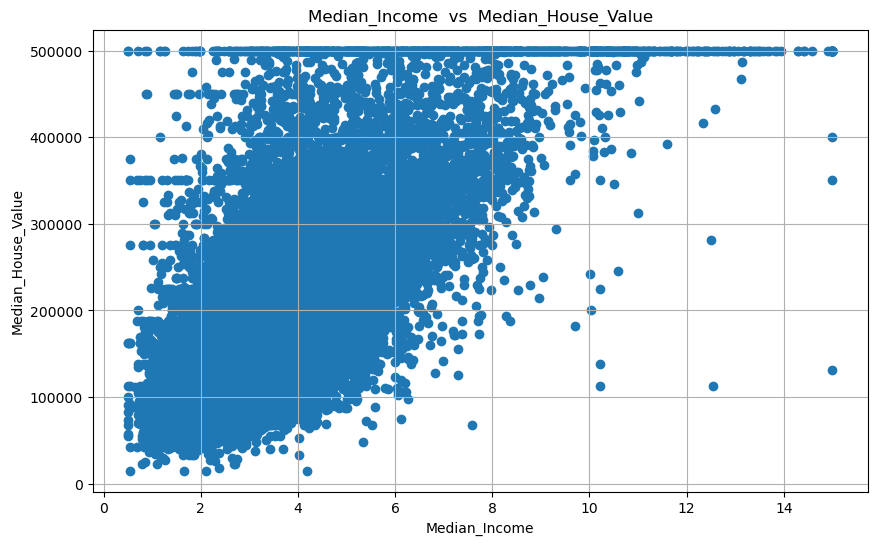

In [20]:
plt.figure(figsize=(10,6))
plt.scatter(df["median_income"],df["median_house_value"])
plt.title("Median_Income  vs  Median_House_Value")
plt.xlabel("Median_Income")
plt.ylabel("Median_House_Value")
plt.grid(True)
plt.show()

### 2. Predicted vs Actual Values

This plot compares the model's predictions with the true house prices. Ideally, the points should lie close to the diagonal reference line, indicating accurate predictions.

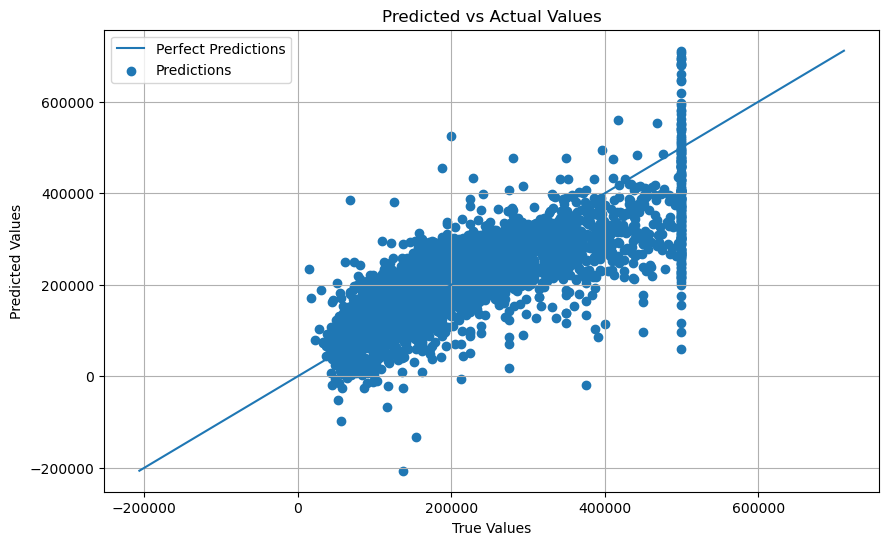

In [21]:
min_value = min(y_test.min(),y_pred.min())
max_value = max(y_test.max(),y_pred.max())
x_coordinates = [min_value,max_value]
y_coordinates = x_coordinates.copy()
plt.figure(figsize=(10,6))
plt.plot(x_coordinates,y_coordinates,label="Perfect Predictions")
plt.scatter(y_test,y_pred,label="Predictions")
plt.title("Predicted vs Actual Values")
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.legend()
plt.grid(True)
plt.show()

### 3. Distribution of House Prices

The histogram displays the distribution of house prices in the dataset. Understanding the target distribution helps identify skewness, outliers, and the overall characteristics of the data.

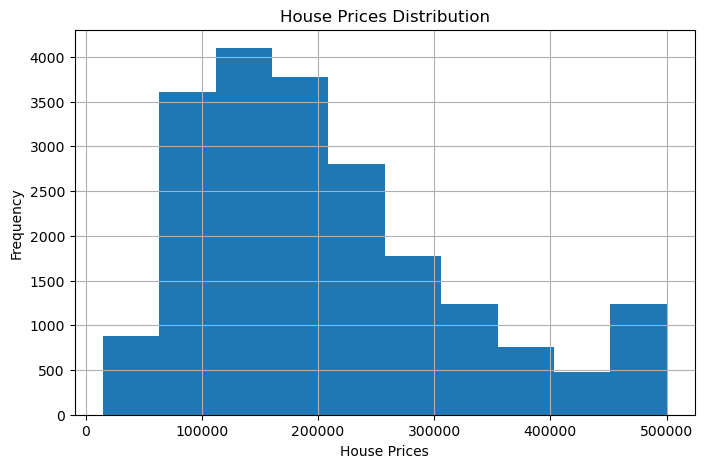

In [22]:
plt.figure(figsize=(8, 5))
plt.hist(df["median_house_value"])
plt.title("House Prices Distribution")
plt.xlabel("House Prices")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

# 12. Conclusion

This notebook demonstrated a complete end-to-end Machine Learning workflow for predicting house prices using the California Housing Dataset.

Starting from data loading and exploration, we performed preprocessing, handled missing values, prepared the data, trained a Linear Regression model, evaluated its performance, and visualized the results.

The model achieved an R² score of approximately 0.61, indicating that it successfully captured a substantial portion of the relationship between the available features and house prices. While Linear Regression provides a strong baseline, the model could be further improved through feature engineering, categorical feature encoding, and more advanced regression algorithms.

This project establishes a solid foundation for future Machine Learning projects involving more sophisticated models and techniques.

# Key Takeaways

- Built a complete end-to-end Machine Learning regression pipeline.
- Applied data preprocessing using Pandas.
- Used StandardScaler to normalize numerical features.
- Trained a Linear Regression model with scikit-learn.
- Evaluated the model using MSE, MAE, and R² Score.
- Visualized both the dataset and the model's predictions using Matplotlib.